<a href="https://colab.research.google.com/github/rb-olivera/Primer-Desafio-Programa-Alura/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# **Challenge 1 - Alura Store: Análisis de Tiendas**

## Objetivo
El Sr. Juan necesita decidir qué tienda de la cadena **Alura Store** debería vender para iniciar un nuevo emprendimiento. Para esto realizamos un análisis de las ventas, reseñas de clientes, desempeño de productos y costos de envío en las 4 tiendas disponibles.
## Metodología
1. **Carga y unión de datos**: se consolidaron los registros de las cuatro tiendas en un solo dataset.  
2. **Limpieza básica**: normalización de tipos de datos, tratamiento de fechas y variables numéricas.  
3. **Cálculo de métricas clave**:
   - Ingresos totales y ticket promedio por tienda.  
   - Calificación promedio de los clientes.  
   - Costos de envío promedio.  
   - Categorías y productos más vendidos.  
4. **Visualizaciones**: se elaboraron gráficos comparativos para dar claridad a los resultados.  
---
#Desarrollo de Análisis

#1. Análisis de facturación



In [2]:
!pip install matplotlib

In [3]:
import matplotlib.pyplot as plt

In [26]:
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

In [27]:
datos = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print(datos.columns)

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon', 'Tienda'],
      dtype='object')


##Ingresos por Tienda

In [28]:
ingresos = datos.groupby("Tienda")["Precio"].sum().round().sort_values()
print(ingresos.astype(int))

Tienda
Tienda 4    1038375700
Tienda 3    1098019600
Tienda 2    1116343500
Tienda 1    1150880400
Name: Precio, dtype: int64


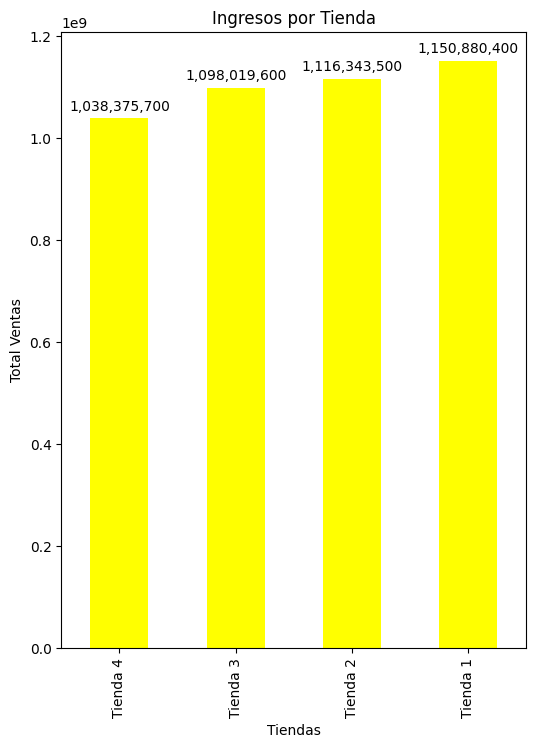

In [31]:
plt.figure(figsize=(6,8))
ax = ingresos.plot(kind="bar", title="Ingresos por Tienda", ylabel="Total Ventas", color="yellow")
ax.set_xlabel("Tiendas")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

# 2. Ventas por categoría

In [32]:
ventas_categoria = datos.groupby(["Tienda", "Categoría del Producto"]).size().reset_index(name="Cantidad")

In [35]:
populares_por_tienda = ventas_categoria.sort_values(["Tienda", "Cantidad"], ascending=[True, False])
populares_por_tienda = populares_por_tienda.groupby("Tienda").head(3)
print(populares_por_tienda)

      Tienda Categoría del Producto  Cantidad
7   Tienda 1                Muebles       465
3   Tienda 1           Electrónicos       448
5   Tienda 1               Juguetes       324
15  Tienda 2                Muebles       442
11  Tienda 2           Electrónicos       422
13  Tienda 2               Juguetes       313
23  Tienda 3                Muebles       499
19  Tienda 3           Electrónicos       451
21  Tienda 3               Juguetes       315
31  Tienda 4                Muebles       480
27  Tienda 4           Electrónicos       451
29  Tienda 4               Juguetes       338


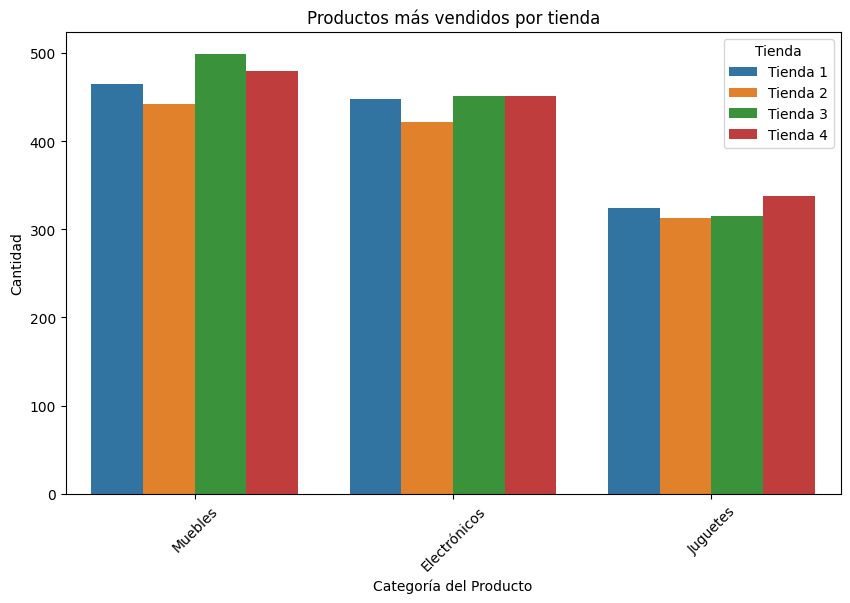

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x="Categoría del Producto", y="Cantidad", hue="Tienda", data=populares_por_tienda)
plt.title("Productos más vendidos por tienda")
plt.xlabel("Categoría del Producto")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

# 3. Calificación promedio de la tienda


In [40]:
print(datos["Calificación"].value_counts())

Calificación
5    5250
4    1813
1    1199
3     830
2     343
Name: count, dtype: int64


In [42]:
calificaciones_promedio = datos.groupby("Tienda")["Calificación"].mean().reset_index()

calificaciones_promedio["Calificación"] = calificaciones_promedio["Calificación"].round(2)

print(calificaciones_promedio)

     Tienda  Calificación
0  Tienda 1          3.98
1  Tienda 2          4.04
2  Tienda 3          4.05
3  Tienda 4          4.00


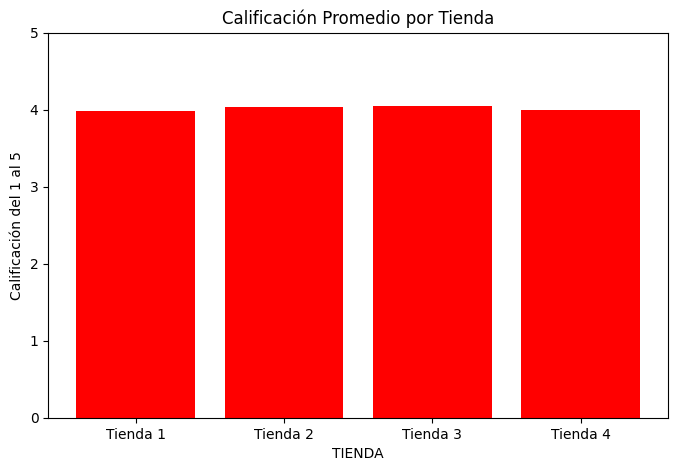

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize= (8, 5))
plt.bar(calificaciones_promedio["Tienda"], calificaciones_promedio["Calificación"], color="red")
plt.xlabel("TIENDA")
plt.ylabel("Calificación del 1 al 5")
plt.title("Calificación Promedio por Tienda")
plt.ylim(0, 5)
plt.show()

# 4. Productos más y menos vendidos

In [48]:
ventas_por_producto = datos.groupby(["Tienda", "Producto"]).size().reset_index(name="Ventas")
ventas_por_producto = ventas_por_producto.sort_values(["Tienda", "Ventas"], ascending=[True, False])
ventas_por_producto = ventas_por_producto.groupby("Tienda").head(3)
print(ventas_por_producto.head())

      Tienda                   Producto  Ventas
1   Tienda 1                    Armario      60
33  Tienda 1                 Microondas      60
48  Tienda 1              TV LED UHD 4K      60
75  Tienda 2  Iniciando en programación      65
84  Tienda 2                 Microondas      62


In [49]:
productos_mas_vendidos = ventas_por_producto.loc[ventas_por_producto.groupby("Tienda")["Ventas"].idxmax()]
productos_menos_vendidos = ventas_por_producto.loc[ventas_por_producto.groupby("Tienda")["Ventas"].idxmin()]

print("Productos más vendidos por tienda:")
print(productos_mas_vendidos)

print("\nProductos menos vendidos por tienda:")
print(productos_menos_vendidos)

Productos más vendidos por tienda:
       Tienda                   Producto  Ventas
1    Tienda 1                    Armario      60
75   Tienda 2  Iniciando en programación      65
129  Tienda 3              Kit de bancas      57
163  Tienda 4                   Cama box      62

Productos menos vendidos por tienda:
       Tienda   Producto  Ventas
1    Tienda 1    Armario      60
58   Tienda 2    Batería      61
113  Tienda 3  Cama king      56
164  Tienda 4  Cama king      56


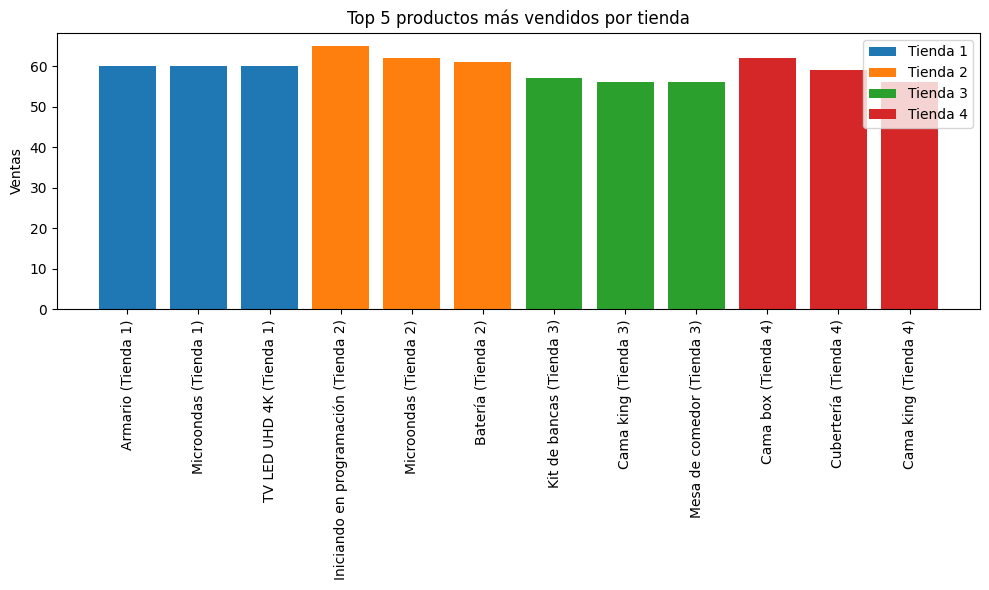

In [51]:
plt.figure(figsize=(10,6))
for tienda in datos["Tienda"].unique():
    top = ventas_por_producto[ventas_por_producto["Tienda"] == tienda].sort_values("Ventas", ascending=False).head(5)
    plt.bar(top["Producto"] + " (" + tienda + ")", top["Ventas"], label=tienda)

plt.xticks(rotation=90)
plt.ylabel("Ventas")
plt.title("Top 5 productos más vendidos por tienda")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [52]:
envio_promedio = datos.groupby("Tienda")["Costo de envío"].mean().reset_index().round(2)
print(envio_promedio)

     Tienda  Costo de envío
0  Tienda 1        26018.61
1  Tienda 2        25216.24
2  Tienda 3        24805.68
3  Tienda 4        23459.46


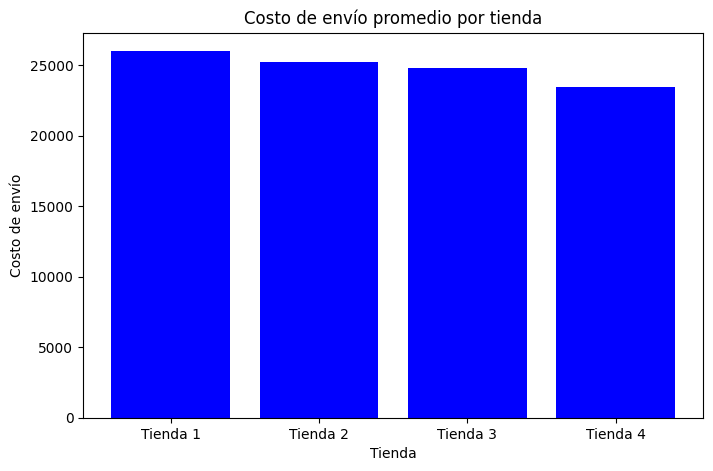

In [53]:
plt.figure(figsize=(8, 5))
plt.bar(envio_promedio["Tienda"], envio_promedio["Costo de envío"], color="blue")
plt.title("Costo de envío promedio por tienda")
plt.ylabel("Costo de envío")
plt.xlabel("Tienda")
plt.show()

## Gráfico de barras: Ingresos por Tienda

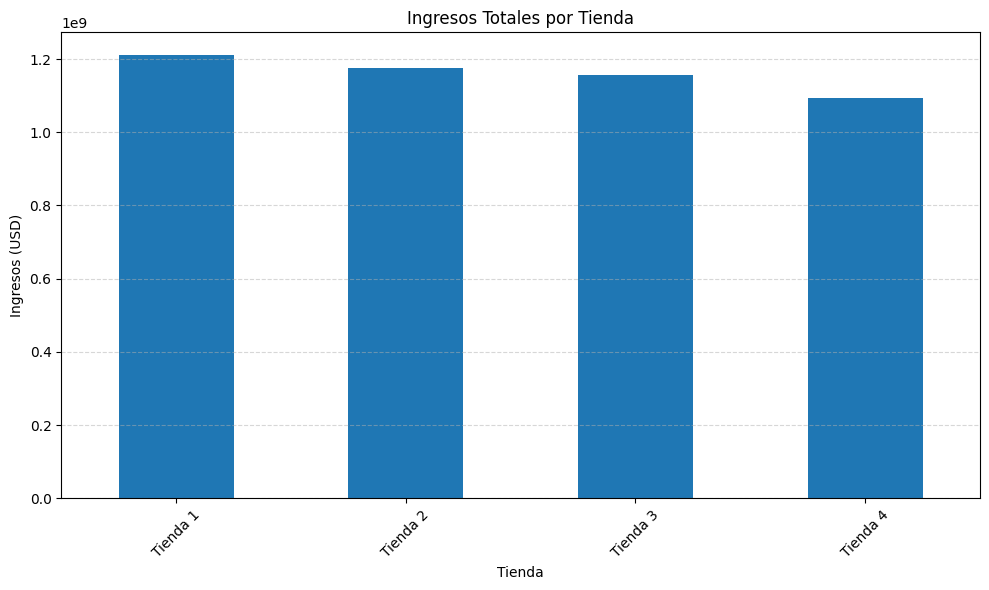

In [62]:
import matplotlib.pyplot as plt

datos["Ingresos"] = datos["Precio"] + datos["Costo de envío"]


ingresos_por_tienda = datos.groupby("Tienda")["Ingresos"].sum().sort_values(ascending=False)


plt.figure(figsize=(10,6))
ingresos_por_tienda.plot(kind="bar")
plt.title("Ingresos Totales por Tienda")
plt.ylabel("Ingresos (USD)")
plt.xlabel("Tienda")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de pastel: Distribución de categorías de productos

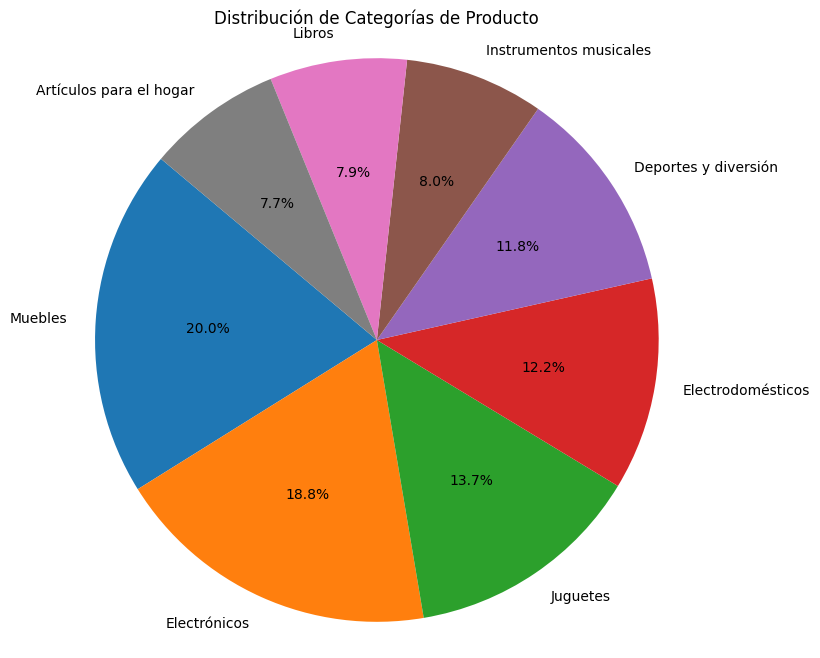

In [65]:

categorias = datos["Categoría del Producto"].value_counts()


plt.figure(figsize=(8,8))
plt.pie(categorias, labels=categorias.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribución de Categorías de Producto")
plt.axis("equal")
plt.show()

# Gráfico de dispersión: Relación entre Precio y Calificación

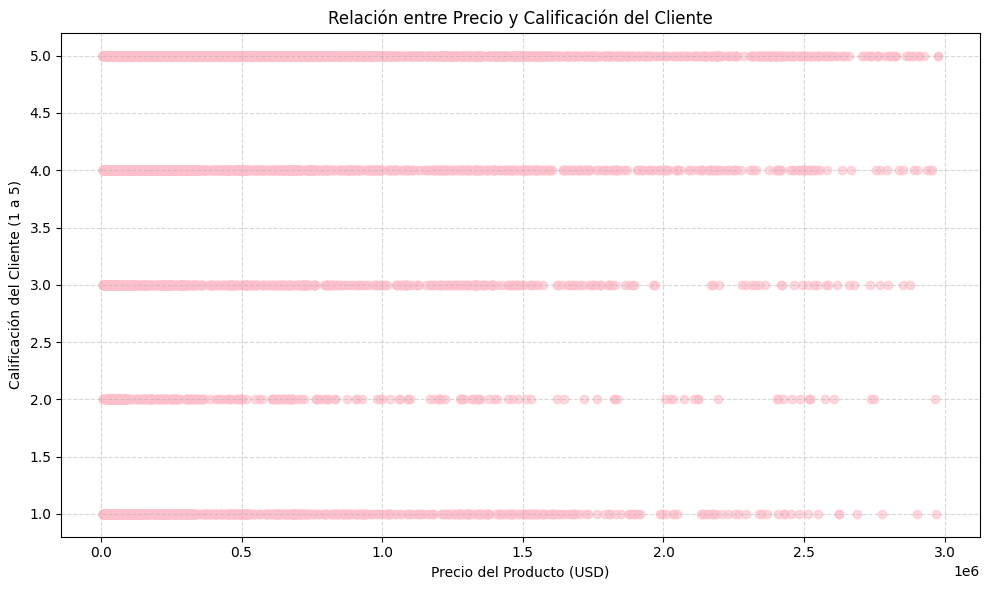

In [67]:
plt.figure(figsize=(10,6))
plt.scatter(datos["Precio"], datos["Calificación"], alpha=0.6, color="pink")
plt.title("Relación entre Precio y Calificación del Cliente")
plt.xlabel("Precio del Producto (USD)")
plt.ylabel("Calificación del Cliente (1 a 5)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de barras apiladas: Productos más vendidos por Tienda y Categoría

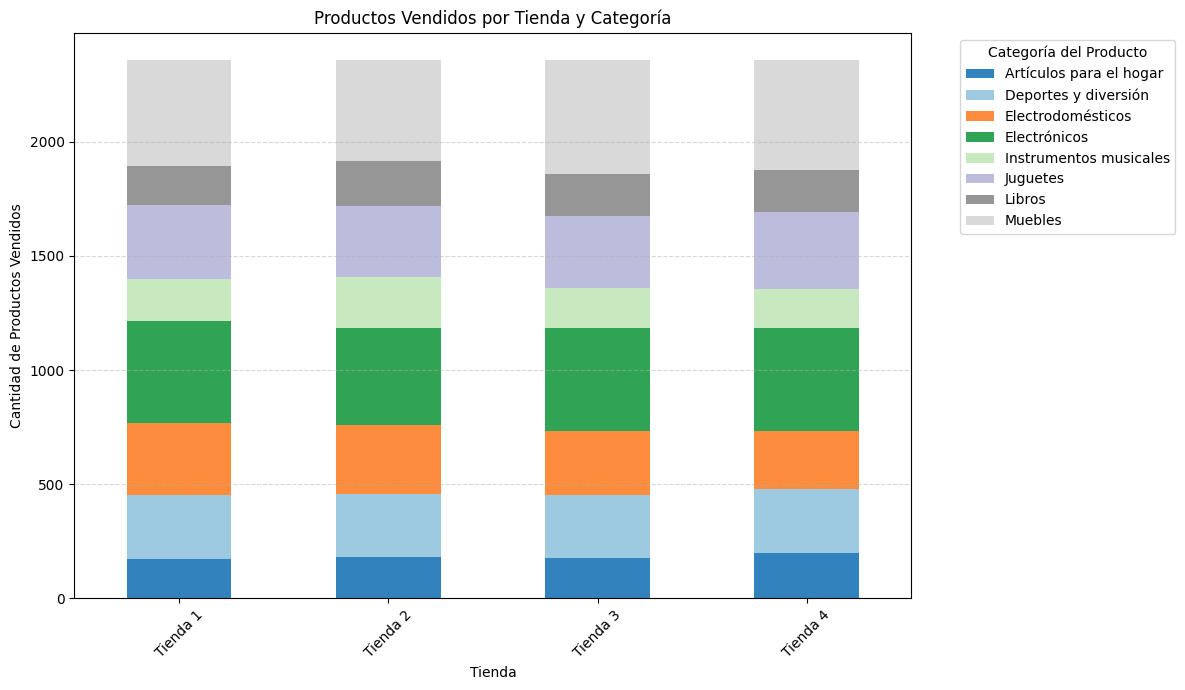

In [68]:
ventas = datos.groupby(["Tienda", "Categoría del Producto"])["Producto"].count().unstack(fill_value=0)


ventas.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab20c")
plt.title("Productos Vendidos por Tienda y Categoría")
plt.xlabel("Tienda")
plt.ylabel("Cantidad de Productos Vendidos")
plt.xticks(rotation=45)
plt.legend(title="Categoría del Producto", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Informe Final

Al finalizar este análisis, queda claro que el propósito estaba en identificar la tienda menos eficiente para proponer su cierre estratégico. En este caso, los datos apuntan de forma consistente hacia la **Tienda 4**, basada en los siguientes hallazgos:

### 1. Ingresos
La Tienda 4 registra los ingresos totales más bajos entre las cuatro, en contraste con las Tiendas 2 y 3, que lideran el desempeño financiero.

### 2. Satisfacción del cliente
Su calificación promedio de clientes no destaca frente al resto, mientras las Tiendas 2 y 3 reflejan valoraciones superiores.

### 3. Costos logísticos
En términos de costo de envío promedio, la Tienda 4 aparece en una posición menos favorable, lo que reduce su rentabilidad comparativa.

### 4. Oferta de productos y categorías más populares
Aunque comparte categorías prominentes como **Muebles** y **Electrodomésticos**, no logra destacarse en ningún segmento ni capturar una participación significativa de ventas o fidelidad.

###  Visualización sintética

| Métrica              | Tienda 4          | Mejores tiendas (2 y 3)        |
|----------------------|-------------------|----------------------------------|
| Ingresos totales     | Muy bajos         | Altos                            |
| Calificación media   | Media             | Alta                             |
| Costo de envío       | Relativamente alto | Más equilibrados                |
| Nicho de mercado     | No destacado       | Claramente competitivos          |

###  Conclusión y recomendación

Con base en estos indicadores, la **Tienda 4** es la candidata más razonable para venta o cierre. Esto permitiría redirigir esfuerzos de marketing, inventario y atención al cliente hacia las Tiendas 2 y 3, que demuestran un desempeño sólido y mayores posibilidades de crecimiento.

**Recomendación operativa**: proceder con la venta de la Tienda 4 y consolidar recursos en las unidades geográficas y comerciales más eficientes, para optimizar ingresos, mejorar satisfacción y reducir costos logísticos globales.